**Remark**: Generated mostly using *qwen3-coder:480b-cloud* model

Here's a Python script that uses a flood-fill approach to find the furthest point from given points within a polygon and visualizes the distance gradient:

This script provides:

1. **Polygon Creation**: Creates a sample polygon with holes (you can replace `create_polygon_with_holes()` with your own polygon)

2. **Rasterization**: Converts the polygon into a grid representation for processing

3. **Flood-Fill Distance Calculation**: Uses a breadth-first search approach to calculate distances from all start points simultaneously

4. **Gradient Visualization**: Shows a color gradient where:
   - Red = furthest from start points
   - Green = closest to start points
   - Contour lines show equal-distance regions

5. **Results**: Displays the furthest point coordinates and maximum distance

**Key Features:**
- Handles polygons with holes correctly
- Supports multiple start points
- Uses 8-connected neighborhood for more accurate distance calculation
- Proper visualization with matplotlib contours
- Efficient flood-fill implementation using deque

**Usage:**
Just replace the `create_polygon_with_holes()` function with your own polygon creation logic, and modify the `start_points` list to specify your reference points.

The visualization will show:
- Color gradient representing distance values
- Blue dots for start points
- Red star for the furthest point
- Contour lines showing distance levels

Rasterizing polygon...
Computing distances using flood-fill...
Finding furthest point...
Furthest point: (np.float64(23.6), np.float64(29.8))
Maximum distance: 36.831


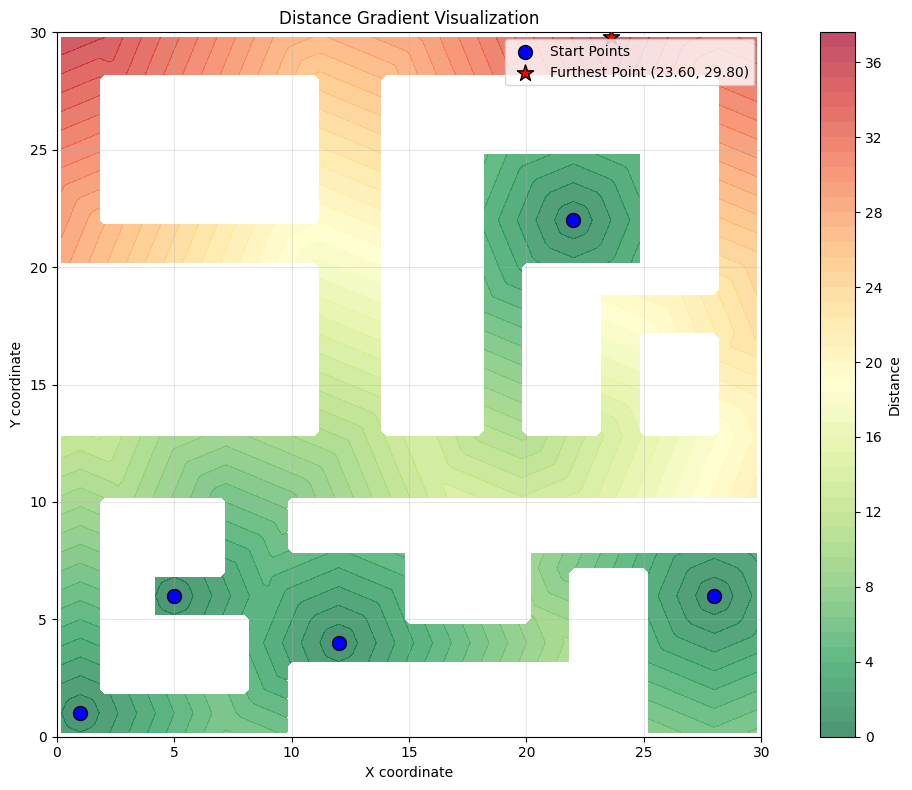

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Point, Polygon
from shapely.affinity import translate
from collections import deque
import math

def create_sample_polygon():
    """Create a sample polygon for demonstration"""
    outer = [
        (0,0), (10, 0),
        (10, 3), (22,3), (22,7), (25,7),(25, 3), (25,0), (30,0),(30, 3), (30, 8), (20, 8), (20, 5), (15,5), (15,8), (10, 8),
        (10, 10), (30, 10), (30, 30), (0, 30),
        (0,20), (11,20), (11,13),(0,13)
    ]
    # offset outer to the inside by 1m (for better visualization of paths near the boundary)
    # outer = LineString(outer).parallel_offset(1, 'left', join_style=2).coords
    # clockwise numbering!
    holes = [
        [(2, 2), (8, 2), (8,5), (4,5), (4,7), (7,7), (7, 10), (2, 10)],
        [(25, 13), (28, 13), (28, 17), (25, 17)],
        [(2, 22), (2, 28), (11, 28), (11, 22)],
        [(14, 13), (14, 28), (28, 28), (28, 19), (23, 19), (23, 13),
            (20, 13), (20, 20), (25, 20), (25, 25), (18, 25), (18, 13)]
    ]
    # outer = LineString(outer).parallel_offset(0.5, 'left', join_style=2).coords

    poly = Polygon(outer, holes=holes)

    return poly

def create_polygon_with_holes():
    """Create a sample polygon with holes for demonstration"""
    # Outer boundary
    outer = [(0, 0), (10, 0), (10, 8), (0, 8)]
    
    # Hole 1
    hole1 = [(2, 2), (4, 2), (4, 4), (2, 4)]
    
    # Hole 2
    hole2 = [(6, 5), (8, 5), (8, 7), (6, 7)]
    
    return Polygon(outer, [hole1, hole2])

def rasterize_polygon(polygon, resolution=0.1):
    """Convert polygon to a binary grid representation"""
    minx, miny, maxx, maxy = polygon.bounds
    
    # Create coordinate arrays
    x_coords = np.arange(minx, maxx + resolution, resolution)
    y_coords = np.arange(miny, maxy + resolution, resolution)
    
    # Initialize grid
    height, width = len(y_coords), len(x_coords)
    grid = np.zeros((height, width), dtype=bool)
    
    # Fill the grid
    for i, y in enumerate(y_coords):
        for j, x in enumerate(x_coords):
            point = Point(x, y)
            if polygon.contains(point):
                grid[i, j] = True
    
    return grid, x_coords, y_coords, minx, miny, resolution

def flood_fill_distance(grid, start_points, x_coords, y_coords, minx, miny, resolution):
    """Flood fill algorithm to compute distances from start points"""
    height, width = grid.shape
    distances = np.full((height, width), np.inf)
    queue = deque()
    
    # Convert start points to grid coordinates and initialize
    for start_point in start_points:
        x, y = start_point
        j = int(round((x - minx) / resolution))
        i = int(round((y - miny) / resolution))
        
        if 0 <= i < height and 0 <= j < width and grid[i, j]:
            distances[i, j] = 0
            queue.append((i, j, 0))
    
    # Directions for 8-connected neighbors
    directions = [(-1,-1), (-1,0), (-1,1), (0,-1), (0,1), (1,-1), (1,0), (1,1)]
    
    # Flood fill
    while queue:
        i, j, dist = queue.popleft()
        
        for di, dj in directions:
            ni, nj = i + di, j + dj
            
            # Check bounds
            if 0 <= ni < height and 0 <= nj < width:
                # Check if it's inside the polygon
                if grid[ni, nj]:
                    new_dist = dist + (math.sqrt(di*di + dj*dj) * resolution)
                    
                    # Update distance if shorter path found
                    if new_dist < distances[ni, nj]:
                        distances[ni, nj] = new_dist
                        queue.append((ni, nj, new_dist))
    
    return distances

def find_furthest_point(distances, grid, x_coords, y_coords, minx, miny, resolution):
    """Find the point with maximum distance"""
    # Mask out areas outside polygon
    masked_distances = np.where(grid, distances, -np.inf)
    
    # Find maximum distance
    max_dist = np.max(masked_distances)
    
    # Find indices of maximum distance
    max_indices = np.where(masked_distances == max_dist)
    if len(max_indices[0]) > 0:
        i, j = max_indices[0][0], max_indices[1][0]
        x = minx + j * resolution
        y = miny + i * resolution
        return (x, y), max_dist
    
    return None, 0

def visualize_results(grid, distances, start_points, furthest_point, 
                     x_coords, y_coords, title="Distance Gradient"):
    """Visualize the results with gradient overlay"""
    fig, ax = plt.subplots(1, 1, figsize=(12, 8))
    
    # Mask distances for areas outside polygon
    masked_distances = np.where(grid, distances, np.nan)
    
    # Create meshgrid for plotting
    X, Y = np.meshgrid(x_coords, y_coords)
    
    # Plot distance gradient
    im = ax.contourf(X, Y, masked_distances, levels=50, cmap='RdYlGn_r', alpha=0.7)
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Distance')
    
    # Plot start points
    if start_points:
        start_x, start_y = zip(*start_points)
        ax.scatter(start_x, start_y, c='blue', s=100, marker='o', 
                  label='Start Points', edgecolors='black', zorder=5)
    
    # Plot furthest point
    if furthest_point:
        ax.scatter(furthest_point[0], furthest_point[1], c='red', s=150, 
                  marker='*', label=f'Furthest Point ({furthest_point[0]:.2f}, {furthest_point[1]:.2f})',
                  edgecolors='black', zorder=5)
    
    # Set labels and title
    ax.set_xlabel('X coordinate')
    ax.set_ylabel('Y coordinate')
    ax.set_aspect('equal')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def main():
    # Create polygon (you can replace this with your own polygon)
    # polygon = create_polygon_with_holes()
    # start_points = [(1, 1), (5, 6)]  # Multiple starting points example
    
    polygon = create_sample_polygon()  # Uncomment to use the more complex sample polygon with holes
    start_points = [(1, 1), (5, 6), (12, 4), (28, 6), (22, 22)]  # Multiple starting points example
    start_points = [(5, 6), (22, 22)]  # Multiple starting points example
    start_points = [(5, 6)]
    start_points = [(27, 11)]
    start_points = [(13, 15)]
    
    print("Rasterizing polygon...")
    grid, x_coords, y_coords, minx, miny, resolution = rasterize_polygon(polygon, resolution=0.2)
    
    print("Computing distances using flood-fill...")
    distances = flood_fill_distance(grid, start_points, x_coords, y_coords, minx, miny, resolution)
    
    print("Finding furthest point...")
    furthest_point, max_distance = find_furthest_point(
        distances, grid, x_coords, y_coords, minx, miny, resolution)
    
    if furthest_point:
        print(f"Furthest point: {furthest_point}")
        print(f"Maximum distance: {max_distance:.3f}")
    else:
        print("No valid furthest point found")
    
    # Visualize results
    visualize_results(grid, distances, start_points, furthest_point, 
                     x_coords, y_coords, "Distance Gradient Visualization")

if __name__ == "__main__":
    main()
